<a href="https://colab.research.google.com/github/duaa-abdul/ML_Project/blob/main/MLassignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***📱 Mobile Price Prediction***

#Data Collection

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv('/content/Mobile Price Prediction Datatset.csv')
df.head()

,Unnamed: 0,Brand me,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
0,0,"LG V30+ (Black, 128 )",4.3,4.0,128.0,6.00,48,13.0,4000,24999
1,1,I Kall K11,3.4,6.0,64.0,4.50,48,12.0,4000,15999
2,2,Nokia 105 ss,4.3,4.0,4.0,4.50,64,16.0,4000,15000
3,3,"Samsung Galaxy A50 (White, 64 )",4.4,6.0,64.0,6.40,48,15.0,3800,18999
4,4,"POCO F1 (Steel Blue, 128 )",4.5,6.0,128.0,6.18,35,15.0,3800,18999


#Data Cleaning

In [ ]:
#Remove unwanted column

df.drop("Unnamed: 0", axis=1, inplace=True)

In [ ]:
#Fix column name

df.rename(columns={"Brand me": "Brand"}, inplace=True)

In [ ]:
#Check missing values

df.isnull().sum()

,0
Brand,0
Ratings,31
RAM,7
ROM,4
Mobile_Size,2
Primary_Cam,0
Selfi_Cam,269
Battery_Power,0
Price,0


In [ ]:
#Remove duplicates

df.drop_duplicates(inplace=True)

In [ ]:
df.dtypes

,0
Brand,object
Ratings,float64
RAM,float64
ROM,float64
Mobile_Size,float64
Primary_Cam,int64
Selfi_Cam,float64
Battery_Power,int64
Price,int64


#EDA (Exploratory Data Analysis)

In [ ]:
#Summary Statistics

df.describe()

,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
count,608.000000,624.000000,626.000000,628.000000,630.000000,437.000000,630.000000,630.000000
mean,4.078289,6.088141,61.407987,5.646947,47.682540,10.121281,3242.571429,17535.779365
std,0.370034,2.654580,50.361982,4.457862,11.227557,6.720599,925.853222,55304.454862
min,2.800000,0.000000,0.000000,2.000000,5.000000,0.000000,1020.000000,479.000000
25%,3.800000,6.000000,32.000000,4.500000,48.000000,5.000000,3000.000000,975.000000
50%,4.100000,6.000000,32.000000,4.580000,48.000000,8.000000,3000.000000,1577.000000
75%,4.400000,6.000000,64.000000,6.220000,48.000000,13.000000,3800.000000,16999.000000
max,4.800000,34.000000,256.000000,44.000000,64.000000,61.000000,6000.000000,573000.000000


In [ ]:
#Info

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 630 entries, 0 to 835
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Brand          630 non-null    object 
 1   Ratings        608 non-null    float64
 2   RAM            624 non-null    float64
 3   ROM            626 non-null    float64
 4   Mobile_Size    628 non-null    float64
 5   Primary_Cam    630 non-null    int64  
 6   Selfi_Cam      437 non-null    float64
 7   Battery_Power  630 non-null    int64  
 8   Price          630 non-null    int64  
dtypes: float64(5), int64(3), object(1)
memory usage: 49.2+ KB


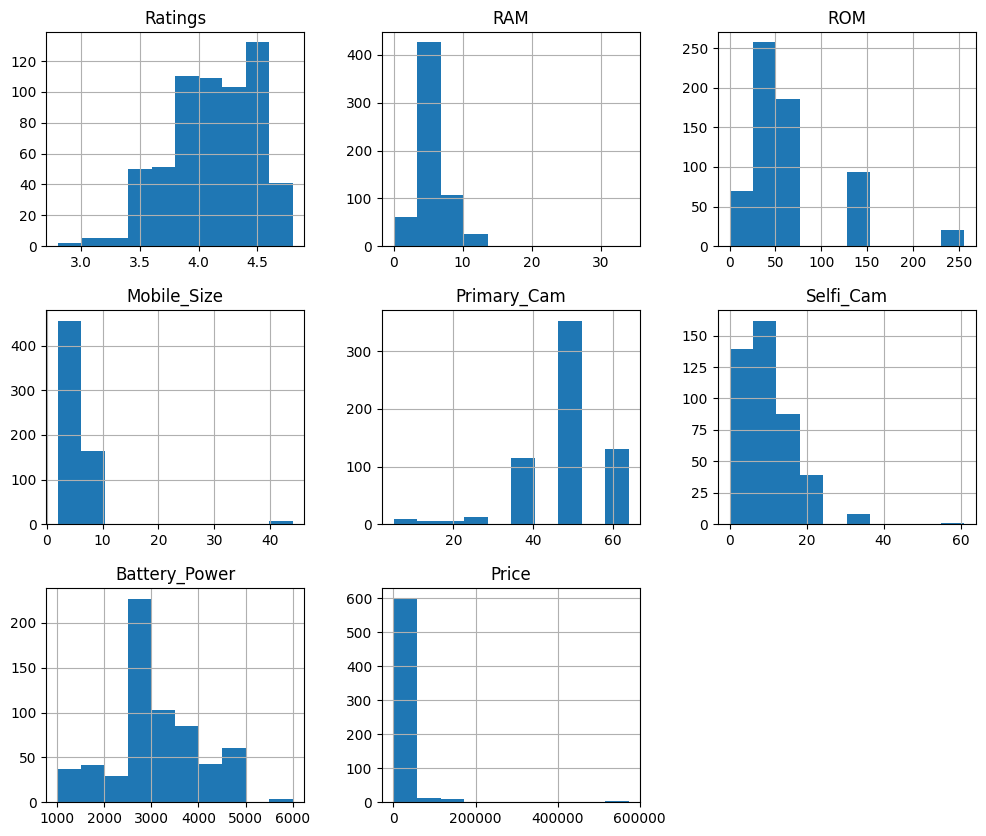

In [ ]:
#Data distribution

df.hist(figsize=(12,10))
plt.show()

#Data Visualization 📊

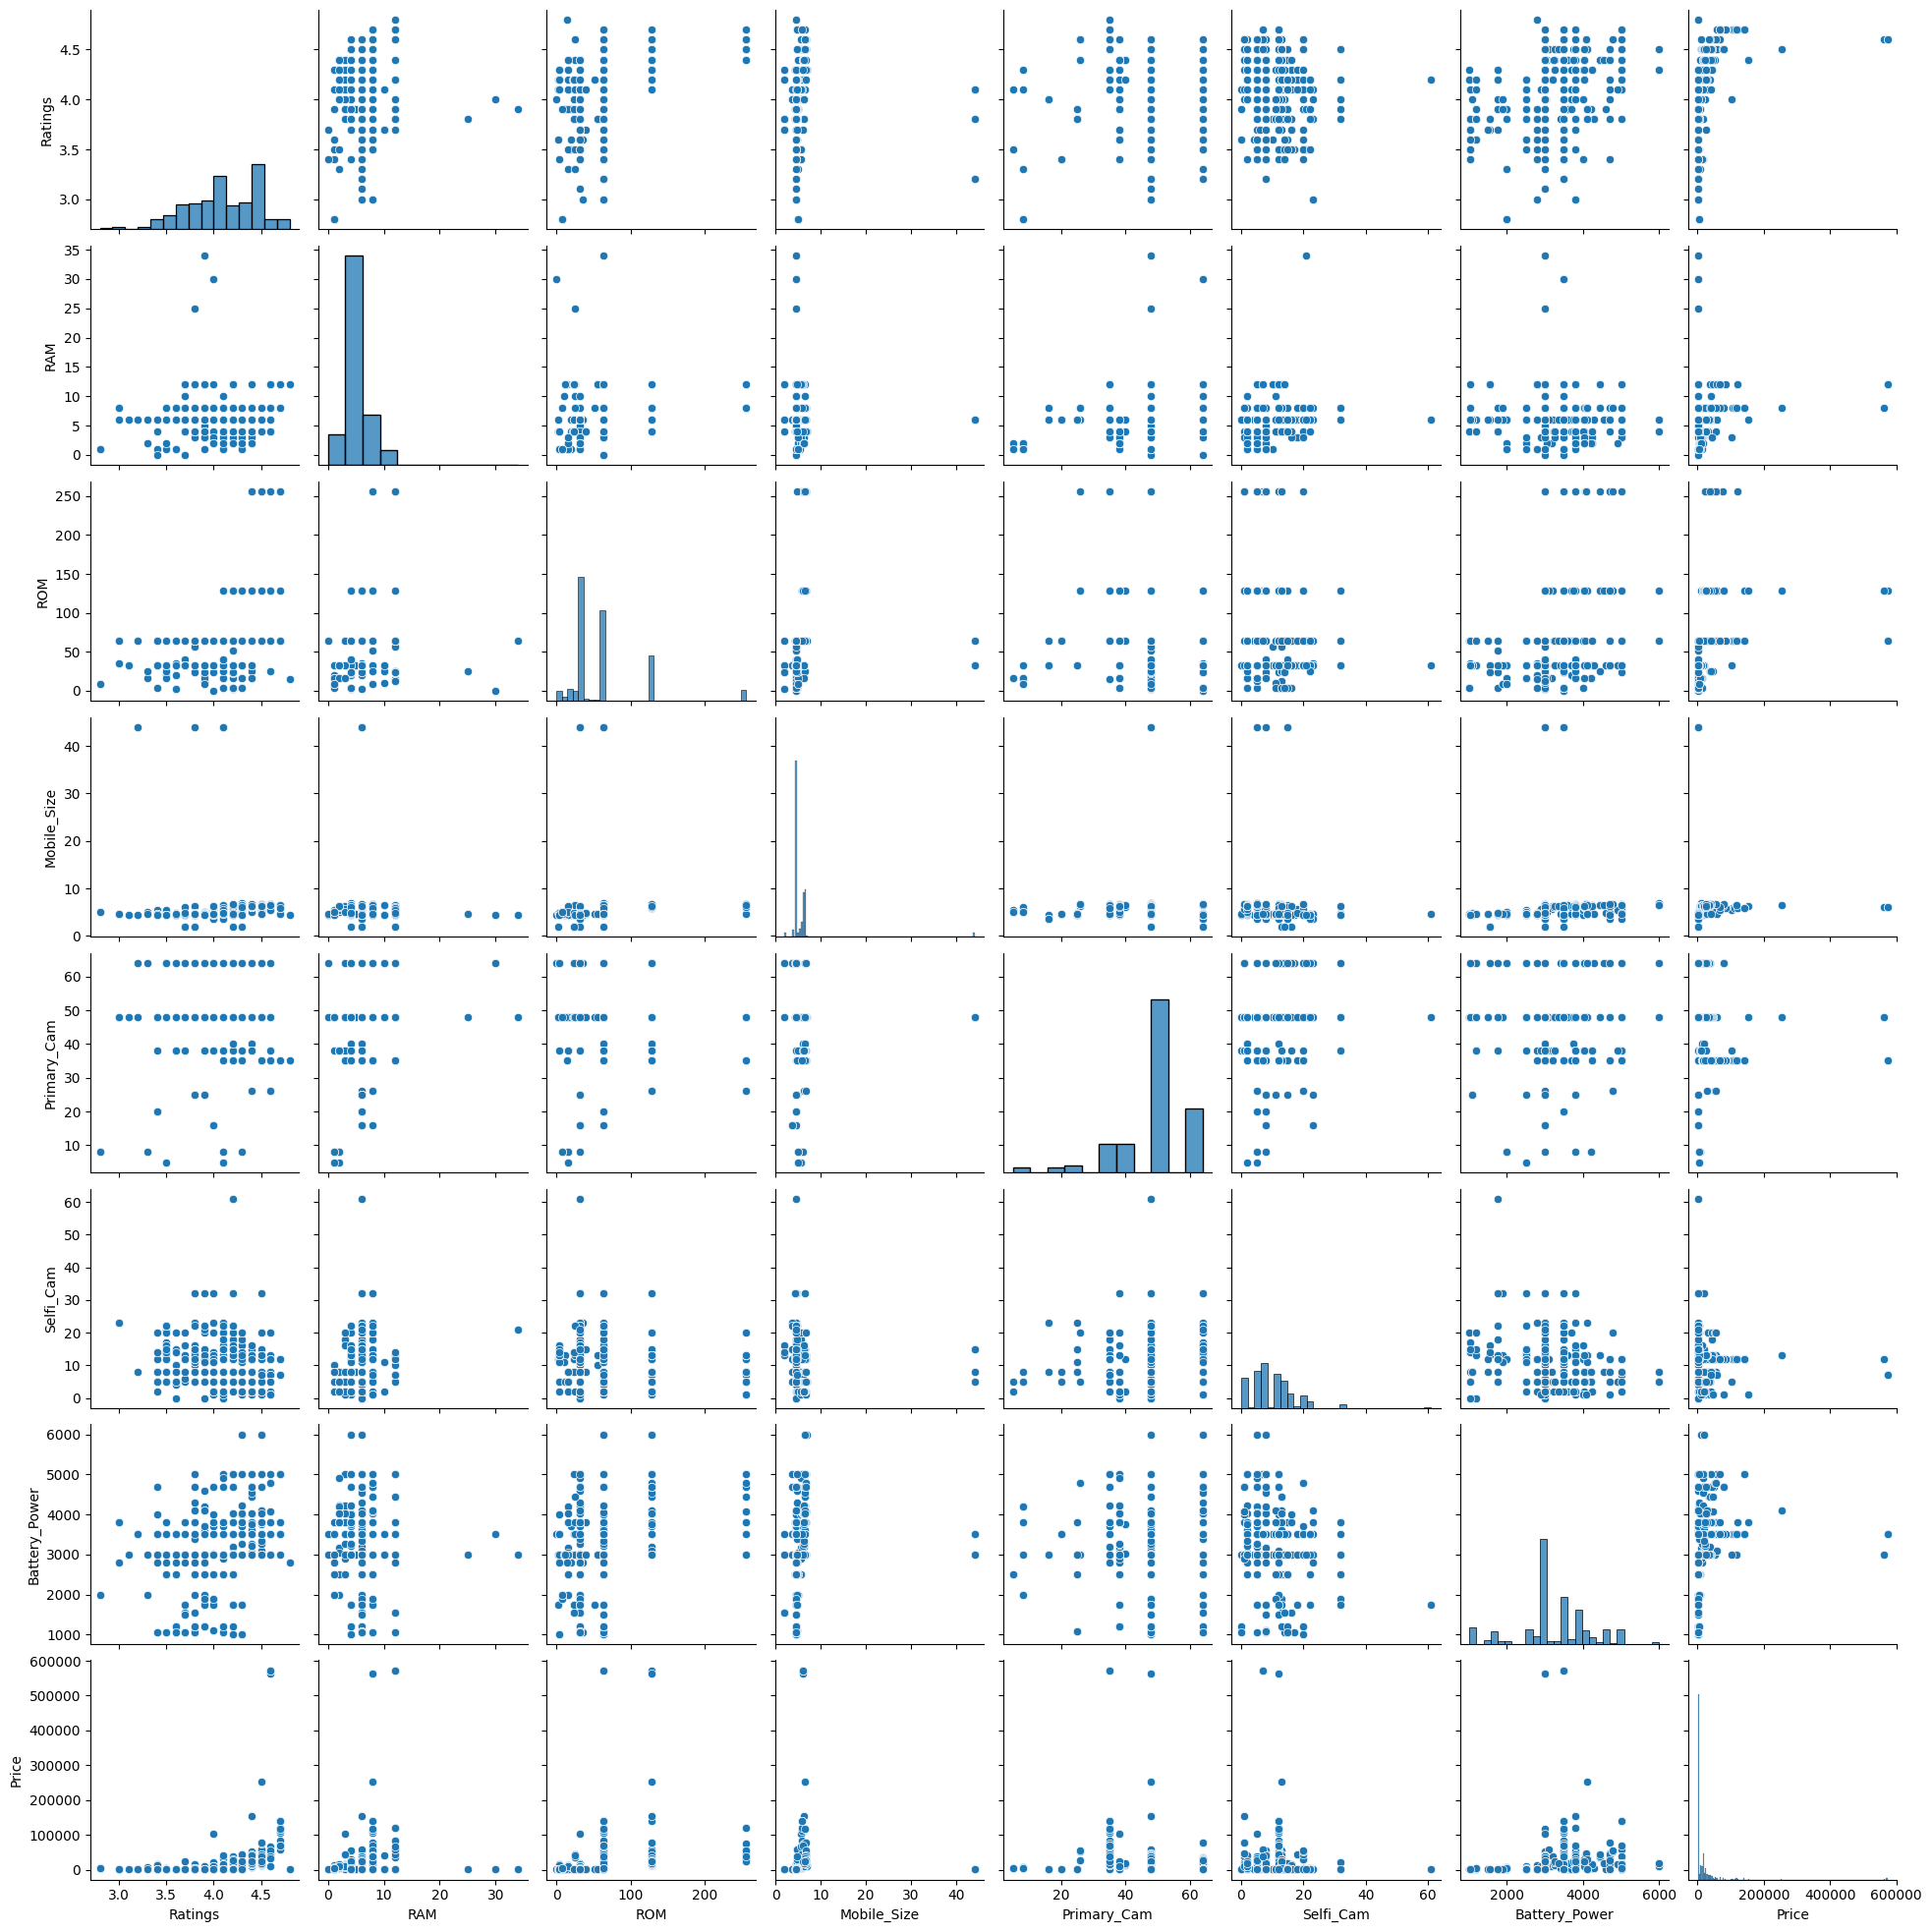

In [ ]:
# Pairplot

sns.pairplot(df)
plt.show()

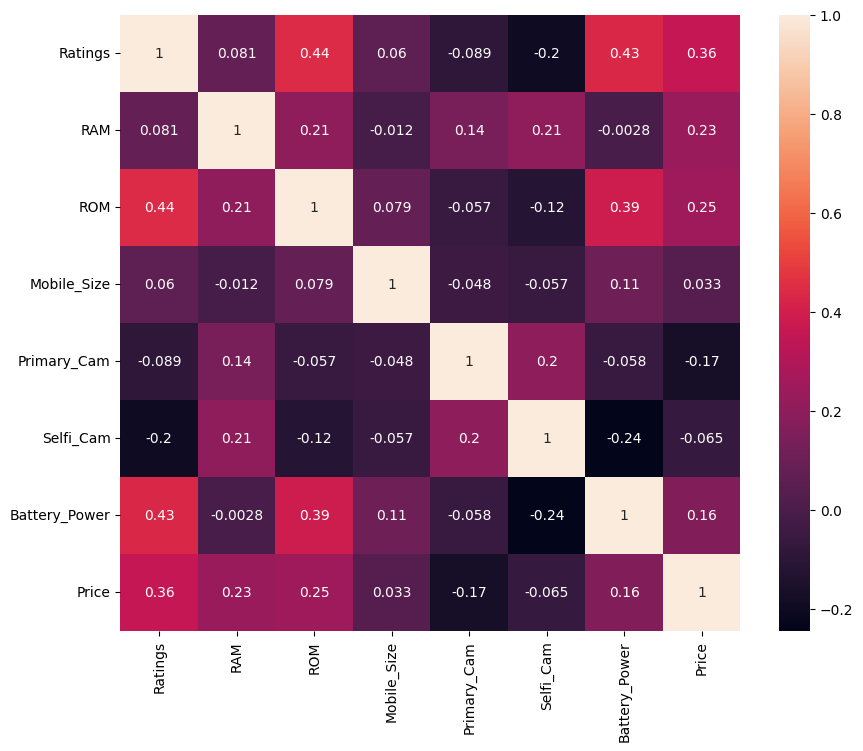

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

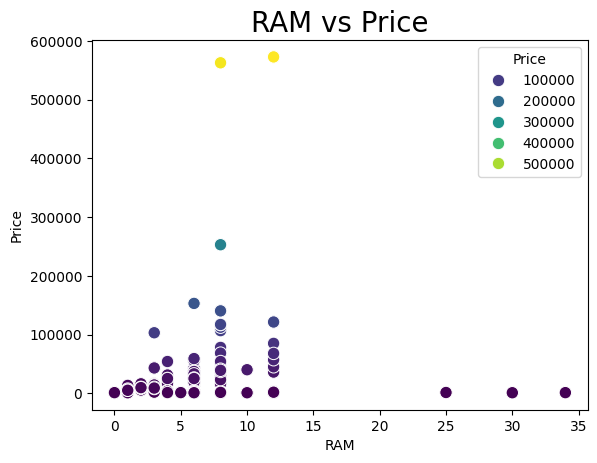

In [ ]:
# Scatter Plot

sns.scatterplot(x='RAM', y='Price',hue='Price',palette='viridis',data=df, s=80)
plt.title('RAM vs Price', fontsize=20)
plt.xlabel('RAM')
plt.ylabel('Price')
plt.show()

#Data Preprocessing

In [ ]:
df = df.fillna(df.mean(numeric_only=True))

# Encode Brand
le = LabelEncoder()
df["Brand"] = le.fit_transform(df["Brand"])

# Create price categories (for classification)
def price_category(price):
    if price < 10000:
        return 0
    elif price < 20000:
        return 1
    elif price < 30000:
        return 2
    else:
        return 3

df["price_range"] = df["Price"].apply(price_category)

# Features Selection
X = df.drop(["Price", "price_range"], axis=1)
y = df["price_range"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#Apply Models

***Logistic Regression***

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

***Decision Tree***

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

***Random Forest***

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

#Evaluation

In [ ]:
# Logistic Regression

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.8412698412698413
[[84  5  0  1]
 [ 4 11  0  0]
 [ 0  2  4  1]
 [ 5  1  1  7]]
              precision    recall  f1-score   support

           0       0.90      0.93      0.92        90
           1       0.58      0.73      0.65        15
           2       0.80      0.57      0.67         7
           3       0.78      0.50      0.61        14

    accuracy                           0.84       126
   macro avg       0.76      0.68      0.71       126
weighted avg       0.84      0.84      0.84       126



In [ ]:
# Decision Tree

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8968253968253969
[[87  3  0  0]
 [ 1 12  2  0]
 [ 0  3  3  1]
 [ 1  1  1 11]]
              precision    recall  f1-score   support

           0       0.98      0.97      0.97        90
           1       0.63      0.80      0.71        15
           2       0.50      0.43      0.46         7
           3       0.92      0.79      0.85        14

    accuracy                           0.90       126
   macro avg       0.76      0.75      0.75       126
weighted avg       0.90      0.90      0.90       126



In [ ]:
# Random Forest

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8888888888888888
[[88  2  0  0]
 [ 2 12  1  0]
 [ 0  4  3  0]
 [ 4  1  0  9]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        90
           1       0.63      0.80      0.71        15
           2       0.75      0.43      0.55         7
           3       1.00      0.64      0.78        14

    accuracy                           0.89       126
   macro avg       0.83      0.71      0.75       126
weighted avg       0.90      0.89      0.88       126



#Confusion Matrix Graph

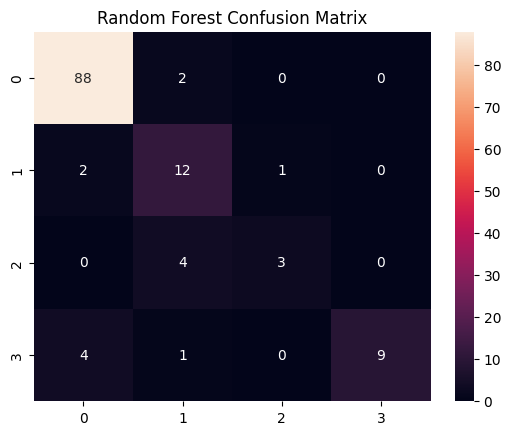

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True)
plt.title("Random Forest Confusion Matrix")
plt.show()

#Model Comparison

In [ ]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.8412698412698413
Decision Tree Accuracy: 0.8968253968253969
Random Forest Accuracy: 0.8888888888888888
